In [3]:
# libraries 
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

#Visualizers
from yellowbrick.classifier import ClassificationReport
from yellowbrick.classifier import ClassPredictionError
from yellowbrick.classifier import ConfusionMatrix
from yellowbrick.classifier import ROCAUC
from yellowbrick.classifier import PrecisionRecallCurve
import matplotlib.pyplot as plt

#Metrics
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import hamming_loss
from sklearn.metrics import log_loss
from sklearn.metrics import zero_one_loss
from sklearn.metrics import matthews_corrcoef
#Classifiers
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [7]:
# read the glass dataset
filename = 'Traindatawell2.csv'
df = pd.read_csv(filename)
df

patterns_colors = ['Blue','Yellow','#996633']


patterns_labels = ['Brine sand', 'Oil sand', 'Shale']

correct_Pattern_labels = df['LFC'].values

df = df.drop(['Samples','DEPTH','VP', 'VS', 'SW', 'SWX', 'VPVS', 'IP', 'IS', 'VSH', 'RHOm', 'RHOfluid'], axis=1)

df.describe()

,GR,NPHI,RHO,PHI,LFC
count,1574.000000,1574.000000,1574.000000,1574.000000,1574.000000
mean,73.464612,0.332971,2.207402,0.300210,2.780178
std,13.693802,0.058844,0.056621,0.026359,1.426732
min,52.300000,0.151000,2.040000,0.143000,1.000000
25%,62.900000,0.290000,2.170000,0.286000,1.000000
50%,68.300000,0.313000,2.200000,0.302000,4.000000
75%,83.775000,0.365000,2.250000,0.316000,4.000000
max,127.000000,0.534000,2.440000,0.376000,4.000000


In [8]:
#Map the labels to the ordinal numbers
df['LFC']=df['LFC'].replace({4:"Shale", 1:"Brine sand",2:"Oil sand"})

In [9]:
# Obtain the class distribution
df['LFC'].value_counts()

Shale         898
Brine sand    568
Oil sand      108
Name: LFC, dtype: int64

In [10]:
# Train, test split
X = df.drop(['LFC'],axis=1)
y = df['LFC']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [11]:
#obtain class labels for future use
classes = y.value_counts().index.tolist()

In [12]:
# select classifiers 
classifiers=[
KNeighborsClassifier(n_neighbors = 7),
LogisticRegression(random_state=0, multi_class='multinomial', solver='newton-cg')]


In [13]:
#Write function for class-centric metrics
# Classification report
def CR_viz():
    def Class_report(model,classes):
        visualizer = ClassificationReport(model, classes=classes, support=True)
        visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
        visualizer.score(X_test, y_test)  # Evaluate the model on the test data
        return visualizer.poof()
    for name in classifiers:
        ax = plt.subplot(1,1,1)
        Class_report(name,classes)

#Class Prediction Error
def CPE_viz():    
    def CPE(model,classes):
        visualizer = ClassPredictionError(model, classes=classes)
        visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
        visualizer.score(X_test, y_test)  # Evaluate the model on the test data 
        return visualizer.poof()  
    for name in classifiers:
        ax = plt.subplot(1,1,1)
        CPE(name,classes)
        
#Confusion matrix
def CM_viz():    
    def CM(model,classes):
        visualizer = ConfusionMatrix(model, classes=classes,percent=True)
        visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
        visualizer.score(X_test, y_test)  # Evaluate the model on the test data 
        return visualizer.poof()  
    for name in classifiers:
        ax = plt.subplot(1,1,1)
        CM(name,classes)
        
#ROC-AUC
def ROC_viz():    
    def ROC(model,classes):
        visualizer = ROCAUC(model, classes=classes)
        visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
        visualizer.score(X_test, y_test)  # Evaluate the model on the test data 
        return visualizer.poof()  
    for name in classifiers:
        ax = plt.subplot(1,1,1)
        ROC(name,classes)

#Precision Recall Curve
def PRC_viz():  
    def PRC(model,classes):
        visualizer = PrecisionRecallCurve(model,classes=classes, per_class=True, iso_f1_curves=False,
    fill_area=False, micro=False)
        visualizer.fit(X_train, y_train)  # Fit the visualizer and the model
        visualizer.score(X_test, y_test)  # Evaluate the model on the test data 
        return visualizer.poof()  
    for name in classifiers:
        ax = plt.subplot(1,1,1)
        PRC(name,classes)


In [14]:
# Write function for aggregate metrics
def classifier_metrics():    
    def metrics(model):
        #     model=model_name()
        model.fit(X_train, y_train)  # Fit the visualizer and the model
        y_pred = model.predict(X_test)
        try: 
            y_prob = model.predict_proba(X_test)
            log_metric = log_loss(y_test,y_prob)
        except:
            y_prob = "Not probablistic"
            log_metric = 0
        else:
            y_pred = model.predict(X_test)
        c_k_s=cohen_kappa_score(y_test,y_pred)
        zero_met=zero_one_loss(y_test,y_pred)
        hl=hamming_loss(y_test,y_pred)
        mc=matthews_corrcoef(y_test,y_pred)
        print('cohen_kappa_score: {0:.3f}'.format(c_k_s))
        print('log_loss: {0:.3f}'.format(log_metric))
        print('zero_one_loss: {0:.3f}'.format(zero_met))
        print('hemming_loss: {0:.3f}'.format(hl))
        print('matthews_corrcoef: {0:.3f}'.format(mc))
    for name in classifiers:
        print (str(name))
        metrics(name)
        print()
        print ("------------------------------------------------------")

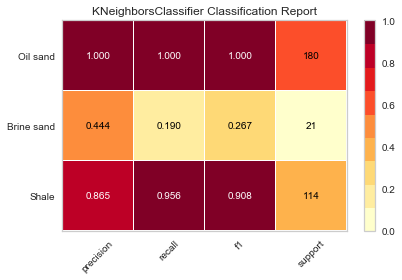

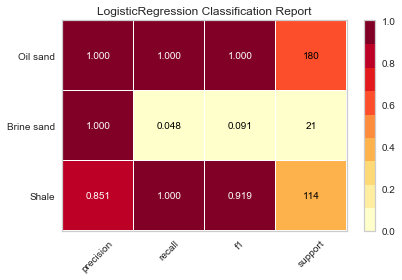

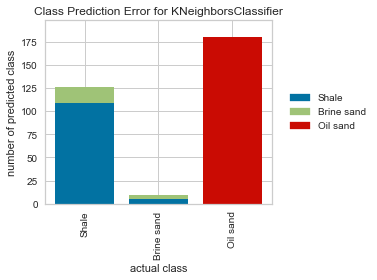

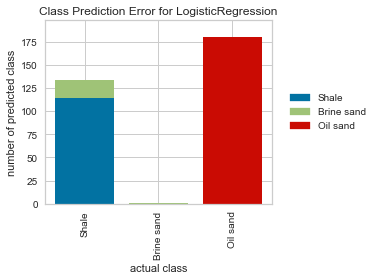

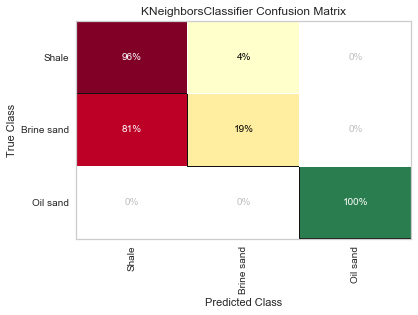

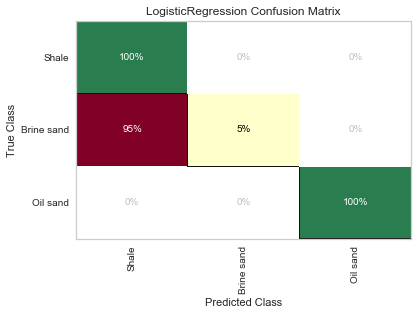

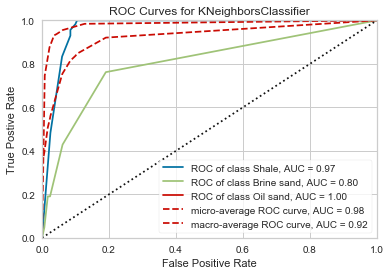

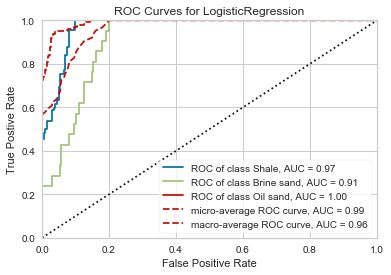

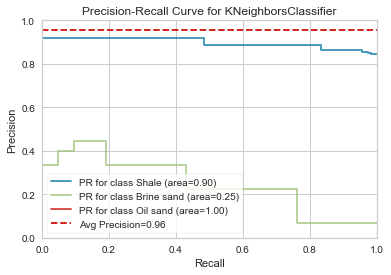

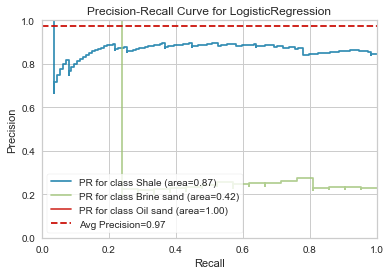

In [15]:
#deploy visualization
visualization =[CR_viz(),CPE_viz(),CM_viz(),ROC_viz(),PRC_viz()]

In [44]:
#Deploy aggregate metrics  
classifier_metrics()

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=7, p=2,
                     weights='uniform')
cohen_kappa_score: 0.867
log_loss: 0.675
zero_one_loss: 0.070
hemming_loss: 0.070
matthews_corrcoef: 0.870

------------------------------------------------------
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='multinomial', n_jobs=None, penalty='l2',
                   random_state=0, solver='newton-cg', tol=0.0001, verbose=0,
                   warm_start=False)
cohen_kappa_score: 0.878
log_loss: 0.179
zero_one_loss: 0.063
hemming_loss: 0.063
matthews_corrcoef: 0.885

------------------------------------------------------
